In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['CUDA_VISIBLE_DEVICES'] = "0"

import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd

In [2]:
import sys
sys.path.append('../data_preprocessing')

In [3]:
import RNN_preprocessing_whole as rp 

In [4]:
import psutil
print(psutil.virtual_memory())  # Shows memory usage

svmem(total=16649175040, available=1894125568, percent=88.6, used=14155198464, free=659656704, active=2186469376, inactive=13170999296, buffers=38674432, cached=1795645440, shared=248360960, slab=328142848)


In [5]:
import gc
gc.collect()

0

In [6]:
print(psutil.virtual_memory()) 

svmem(total=16649175040, available=1879535616, percent=88.7, used=14169788416, free=645054464, active=2186956800, inactive=13184036864, buffers=38690816, cached=1795641344, shared=248360960, slab=328142848)


In [7]:
X_seq_train = rp.X_seq_train
X_seq_test = rp.X_seq_test
y_seq_train = rp.y_seq_train
y_seq_test = rp.y_seq_test

In [8]:
# Clear memory associated with the module
del rp
if 'RNN_preprocessing_whole' in sys.modules:
    del sys.modules['RNN_preprocessing_whole']

# Clear memory from global variables if needed
gc.collect()

5

In [9]:
X_seq_train, X_seq_val, y_seq_train, y_seq_val = train_test_split(X_seq_train, y_seq_train, test_size=0.2, random_state=0)

In [10]:
X_train = X_seq_train
X_val = X_seq_val
y_train = y_seq_train
y_val = y_seq_val 

In [11]:
# Delete the training/test split variables after they are used
del X_seq_train, X_seq_val, y_seq_train, y_seq_val

# Force garbage collection
gc.collect()

0

LSTM

In [12]:
#Long Short Term Memory model
def model_lstm (input_shape, output_shape):
    model = keras.Sequential(
        [
            layers.LSTM(32, input_shape=input_shape, activation="tanh", return_sequences=True),
            layers.LSTM(16, activation="tanh", return_sequences=True),
            layers.Dense(8, activation="relu"),
            layers.Dense(output_shape, activation="softmax"),
        ]
    )
    model.compile(loss="categorical_crossentropy", optimizer = "adam", metrics=['accuracy'])
    return model

In [13]:
seq_length = 10

In [14]:
#Model for the BiPo 214 chain
model = model_lstm((seq_length, X_train.shape[2]), y_train.shape[2])

model.summary()

2025-02-26 15:02:23.912058: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 10, 32)            4992      
                                                                 
 lstm_1 (LSTM)               (None, 10, 16)            3136      
                                                                 
 dense (Dense)               (None, 10, 8)             136       
                                                                 
 dense_1 (Dense)             (None, 10, 10)            90        
                                                                 
Total params: 8354 (32.63 KB)
Trainable params: 8354 (32.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [15]:
#callback for reducing the learning rate and stopping early in case the loss function hits a plateau
callbacks = [
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, verbose=1, min_lr=1E-6),
    tf.keras.callbacks.EarlyStopping(patience=10, verbose=1, baseline=None, restore_best_weights=True)
]

In [16]:
# Clear any previous session
tf.keras.backend.clear_session()
gc.collect()


6443

In [17]:
# Train model 1
history = model.fit(X_train, y_train, epochs=200, batch_size=256, verbose=2,
                      validation_data=(X_val, y_val),
                      callbacks=callbacks)

Epoch 1/200
16108/16108 - 393s - loss: 0.7936 - accuracy: 0.6611 - val_loss: 0.6625 - val_accuracy: 0.7134 - lr: 0.0010 - 393s/epoch - 24ms/step
Epoch 2/200
16108/16108 - 384s - loss: 0.6469 - accuracy: 0.7191 - val_loss: 0.6487 - val_accuracy: 0.7153 - lr: 0.0010 - 384s/epoch - 24ms/step
Epoch 3/200
16108/16108 - 328s - loss: 0.6364 - accuracy: 0.7225 - val_loss: 0.6305 - val_accuracy: 0.7250 - lr: 0.0010 - 328s/epoch - 20ms/step
Epoch 4/200
16108/16108 - 295s - loss: 0.6325 - accuracy: 0.7236 - val_loss: 0.6261 - val_accuracy: 0.7262 - lr: 0.0010 - 295s/epoch - 18ms/step
Epoch 5/200
16108/16108 - 295s - loss: 0.6298 - accuracy: 0.7244 - val_loss: 0.6373 - val_accuracy: 0.7216 - lr: 0.0010 - 295s/epoch - 18ms/step
Epoch 6/200
16108/16108 - 295s - loss: 0.6275 - accuracy: 0.7251 - val_loss: 0.6237 - val_accuracy: 0.7271 - lr: 0.0010 - 295s/epoch - 18ms/step
Epoch 7/200
16108/16108 - 295s - loss: 0.6261 - accuracy: 0.7256 - val_loss: 0.6221 - val_accuracy: 0.7266 - lr: 0.0010 - 295s/epo

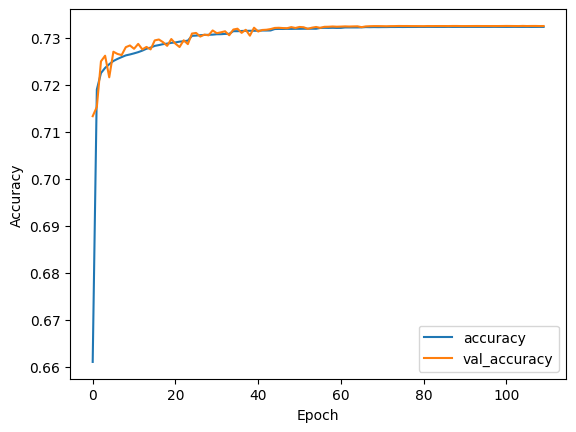

In [18]:
#plotting the accuracy of the first model
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

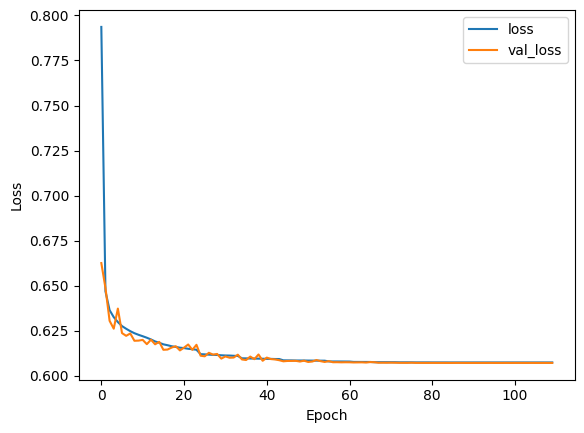

In [19]:
#plotting the loss over epoch for the first model
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

In [28]:
# Predict the labels for the test set
y_pred = model.predict(X_seq_test)

27013/27013 [==============================] - 163s 6ms/step


In [45]:
#convert predictions to class labels
y_pred_classes = np.argmax(y_pred, axis=2)

# Convert one-hot encoded true labels back to class labels
y_test_classes = np.argmax(y_seq_test, axis=2)

In [47]:
# Reshape or flatten the arrays
y_test_classes_flat = y_test_classes.reshape(-1)  # Flatten y_test_classes1
y_pred_classes_flat = y_pred_classes.reshape(-1)  # Flatten y_pred_classes1

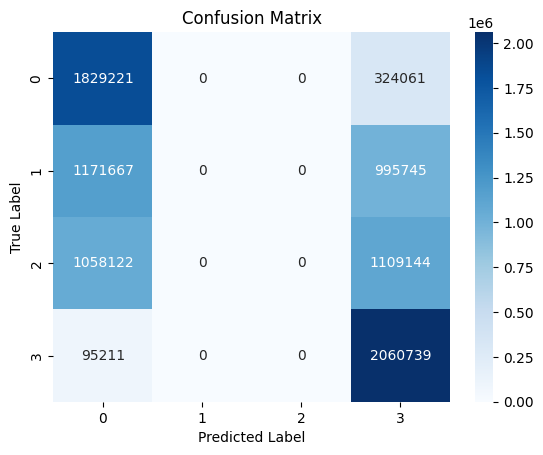

In [50]:
# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test_classes_flat, y_pred_classes_flat)

# Plot the confusion matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [33]:
# Calculate metrics
precision_macro = precision_score(y_test_classes_flat, y_pred_classes_flat, average='macro')
recall_macro = recall_score(y_test_classes_flat, y_pred_classes_flat, average='macro')
f1_macro = f1_score(y_test_classes_flat, y_pred_classes_flat, average='macro')

precision_micro = precision_score(y_test_classes_flat, y_pred_classes_flat, average='micro')
recall_micro = recall_score(y_test_classes_flat, y_pred_classes_flat, average='micro')
f1_micro = f1_score(y_test_classes_flat, y_pred_classes_flat, average='micro')

precision_weighted = precision_score(y_test_classes_flat, y_pred_classes_flat, average='weighted')
recall_weighted = recall_score(y_test_classes_flat, y_pred_classes_flat, average='weighted')
f1_weighted = f1_score(y_test_classes_flat, y_pred_classes_flat, average='weighted')

# Create a summary table for F1, Recall, and Precision
metrics_summary = pd.DataFrame({
    'Metric': [
        'Precision (Macro)', 'Recall (Macro)', 'F1 Score (Macro)',
        'Precision (Micro)', 'Recall (Micro)', 'F1 Score (Micro)',
        'Precision (Weighted)', 'Recall (Weighted)', 'F1 Score (Weighted)'
    ],
    'Score': [
        precision_macro, recall_macro, f1_macro,
        precision_micro, recall_micro, f1_micro,
        precision_weighted, recall_weighted, f1_weighted
    ]
})

# Display the table
print(metrics_summary)

ValueError: multiclass-multioutput is not supported

In [ ]:
accuracy = accuracy_score(y_test_classes_flat, y_pred_classes_flat)
print({f"Accuracy:{accuracy}"})

In [20]:
#save the first trained model
model.save('../models/model_lstm_whole.h5')

/home/pipc06/.local/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
from collections import Counter

def signal_detection_metrics(test_classes, pred_classes, signal_classes):
    """
    Calculate the following metrics for each specified class:
    1) Percentage of actual signal events detected w.r.t total signal events.
    2) Percentage of actual signal detected w.r.t. the predicted signal events.
    3) Breakdown of misclassified predictions for each class.
    4) Total number of events classified as the given class.

    Parameters:
    - test_classes: Array-like, ground truth labels
    - pred_classes: Array-like, predicted labels
    - signal_classes: int or list, class/classes for which the metrics should be computed

    Returns:
    - A dictionary containing results for each class.
    """
    
    # Ensure signal_classes is a list
    if isinstance(signal_classes, int):
        signal_classes = [signal_classes]
    
    # Convert to NumPy arrays for easier computation
    test_classes = np.array(test_classes)
    pred_classes = np.array(pred_classes)

    results = {}

    for cls in signal_classes:
        # True Positives (TP): cases where both test and pred match the class
        tp = np.sum((test_classes == cls) & (pred_classes == cls))
        
        # Total actual signal events for the class
        total_signal_events = np.sum(test_classes == cls)
        
        # Total predicted signal events for the class
        total_predicted_signal = np.sum(pred_classes == cls)

        # Compute percentages
        percentage_actual_signal_detected = (tp / total_signal_events * 100) if total_signal_events > 0 else 0
        percentage_detected_signal_accuracy = (tp / total_predicted_signal * 100) if total_predicted_signal > 0 else 0

        # Misclassification breakdown: Find what other classes were mistaken as this class
        misclassified_counts = Counter(test_classes[pred_classes == cls])
        if cls in misclassified_counts:
            del misclassified_counts[cls]  # Remove true positives from misclassification count

        # Convert misclassification counts to percentages
        misclassification_percentages = {other_cls: (count / total_predicted_signal * 100) 
                                         for other_cls, count in misclassified_counts.items()}

        # Store results
        results[cls] = {
            "Total events classified as this class": total_predicted_signal,
            "Percentage of actual signal events detected": percentage_actual_signal_detected,
            "Percentage of detected signal accuracy": percentage_detected_signal_accuracy,
            "Misclassification breakdown (%)": misclassification_percentages
        }

    # Print results
    for cls, metrics in results.items():
        print(f"\nResults for class {cls}:")
        print(f"  - Total events classified as this class: {metrics['Total events classified as this class']}")
        print(f"  - Percentage of actual signal events detected: {metrics['Percentage of actual signal events detected']:.2f}%")
        print(f"  - Percentage of detected signal accuracy: {metrics['Percentage of detected signal accuracy']:.2f}%")

        if metrics["Misclassification breakdown (%)"]:
            print(f"  - Misclassified as other classes:")
            for mis_cls, mis_perc in metrics["Misclassification breakdown (%)"].items():
                print(f"    - Class {mis_cls}: {mis_perc:.2f}%")

    return results

In [ ]:
result = signal_detection_metrics(y_test_classes_flat, y_pred_classes_flat, [1, 2, 4, 5])
print(result)